# Atividade Integrada — Ciência de Dados aplicada às Importações Brasileiras e Geopolítica

Este notebook desenvolve o **Tema 2**, aplicando conceitos fundamentais de Ciência de Dados e Inteligência Artificial aos dados de importações brasileiras.

## Objetivo

Investigar como dados de importação podem ajudar a compreender a vulnerabilidade do Brasil diante de conflitos geopolíticos internacionais, especialmente em setores estratégicos como energia, combustíveis, fertilizantes e logística.

## 1. Importação das bibliotecas

Nesta etapa são carregadas as bibliotecas necessárias para leitura da base, análise de dados, geração de gráficos e modelagem simples de IA.

In [2]:
import os
import re
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)

## 2. Localização automática do banco de dados

O dataset baixado do Kaggle vem em formato de banco SQLite. O código abaixo procura automaticamente o maior arquivo dentro da pasta `dados`, evitando erros com nomes diferentes de arquivo.

In [3]:
arquivos_encontrados = []

for raiz, pastas, arquivos in os.walk("dados"):
    for arquivo in arquivos:
        caminho = os.path.join(raiz, arquivo)
        tamanho = os.path.getsize(caminho)
        arquivos_encontrados.append((caminho, tamanho))

arquivos_encontrados = sorted(arquivos_encontrados, key=lambda x: x[1], reverse=True)

print("Arquivos encontrados:")
for caminho, tamanho in arquivos_encontrados:
    print(caminho, "-", tamanho, "bytes")

caminho_banco = arquivos_encontrados[0][0]

print("\nArquivo selecionado automaticamente:")
print(caminho_banco)

Arquivos encontrados:
dados\archive\database.db - 3430244352 bytes
dados\archive\importacoes.csv.db - 0 bytes
dados\archive\importacoes_brasil.db - 0 bytes

Arquivo selecionado automaticamente:
dados\archive\database.db


## 3. Leitura do banco e escolha da tabela de importações

O banco possui várias tabelas. Para esta atividade, eu usei a tabela de importações completa,que possui: ano, país, produto, valor FOB e volume.

In [4]:
with open(caminho_banco, "rb") as f:
    assinatura = f.read(30)

print("Assinatura do arquivo:", assinatura)

Assinatura do arquivo: b'SQLite format 3\x00\x10\x00\x01\x01\x00@  \x00\x00\x00\xc5\x00\x0c'


In [5]:
conexao = sqlite3.connect(caminho_banco)

tabelas = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conexao
)

print("Tabelas encontradas:")
display(tabelas)

Tabelas encontradas:


,name
0,co_ncm
1,co_pais
2,co_unid
3,co_urf
4,co_via
5,exp_completa
6,imp_completa
7,ncm_unidade


In [6]:
def colunas_da_tabela(nome_tabela):
    info = pd.read_sql_query(f'PRAGMA table_info("{nome_tabela}")', conexao)
    return info["name"].tolist()

resumo_tabelas = []

for nome_tabela in tabelas["name"]:
    cols = colunas_da_tabela(nome_tabela)
    texto_colunas = " ".join(cols).upper()

    termos_importantes = [
        "CO_ANO", "CO_PAIS", "CO_NCM",
        "VL_FOB", "KG_LIQUIDO"
    ]

    pontuacao = sum(1 for termo in termos_importantes if termo in texto_colunas)

    resumo_tabelas.append({
        "tabela": nome_tabela,
        "quantidade_colunas": len(cols),
        "pontuacao": pontuacao,
        "colunas": cols
    })

resumo_tabelas = pd.DataFrame(resumo_tabelas).sort_values(
    by=["pontuacao", "quantidade_colunas"],
    ascending=False
)

display(resumo_tabelas[["tabela", "quantidade_colunas", "pontuacao", "colunas"]])

,tabela,quantidade_colunas,pontuacao,colunas
5,exp_completa,11,5,"[CO_ANO, CO_MES, CO_NCM, CO_UNID, CO_PAIS, SG_..."
6,imp_completa,11,5,"[CO_ANO, CO_MES, CO_NCM, CO_UNID, CO_PAIS, SG_..."
0,co_ncm,14,1,"[CO_NCM, CO_UNID, CO_SH6, CO_PPE, CO_PPI, CO_F..."
1,co_pais,6,1,"[CO_PAIS, CO_PAIS_ISON3, CO_PAIS_ISOA3, NO_PAI..."
2,co_unid,3,0,"[CO_UNID, NO_UNID, SG_UNID]"
7,ncm_unidade,3,0,"[CO_UNID, NO_UNID, SG_UNID]"
3,co_urf,2,0,"[CO_URF, NO_URF]"
4,co_via,2,0,"[CO_VIA, NO_VIA]"


In [7]:
nome_tabela = resumo_tabelas.iloc[0]["tabela"]

print("Tabela selecionada para análise:")
print(nome_tabela)

df = pd.read_sql_query(f'SELECT * FROM "{nome_tabela}"', conexao)

print("Base carregada com sucesso!")
print("Linhas e colunas:", df.shape)

display(df.head())

Tabela selecionada para análise:
exp_completa
Base carregada com sucesso!
Linhas e colunas: (23358760, 11)


,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB
0,1997,11,20079990,10,158,RJ,4,717700,0,200,540
1,1997,11,48064000,10,63,SP,7,1010900,0,58792,90186
2,1997,11,2071300,10,351,SC,1,925100,0,57165,20767
3,1997,11,19021100,10,586,MS,9,910600,0,12,9
4,1997,11,90319090,10,40,ND,4,717700,0,6,250


## 4. Limpeza, padronização e filtro para anos recentes

O enunciado orienta trabalhar com **anos recentes**. Por isso, após carregar os dados, será criado um recorte a partir de 2015.

As principais variáveis utilizadas são:

- `CO_ANO` — ano;
- `CO_PAIS` — país de origem;
- `CO_NCM` — produto importado;
- `VL_FOB` — valor importado em dólar;
- `KG_LIQUIDO` — volume importado.

In [8]:
print("Colunas disponíveis na tabela escolhida:")
for col in df.columns:
    print(col)

Colunas disponíveis na tabela escolhida:
CO_ANO
CO_MES
CO_NCM
CO_UNID
CO_PAIS
SG_UF_NCM
CO_VIA
CO_URF
QT_ESTAT
KG_LIQUIDO
VL_FOB


In [9]:
col_ano = "CO_ANO"
col_pais = "CO_PAIS"
col_produto = "CO_NCM"
col_valor = "VL_FOB"
col_peso = "KG_LIQUIDO"

dados = pd.DataFrame()

dados["ano"] = pd.to_numeric(df[col_ano], errors="coerce")
dados["pais"] = df[col_pais].astype(str)
dados["produto"] = df[col_produto].astype(str)
dados["valor_fob"] = pd.to_numeric(df[col_valor], errors="coerce")
dados["kg_liquido"] = pd.to_numeric(df[col_peso], errors="coerce")

dados = dados.dropna(subset=["ano", "valor_fob"])
dados = dados[dados["valor_fob"] >= 0]

# Filtro para anos recentes
dados = dados[dados["ano"] >= 2015]

print("Base simplificada criada com sucesso!")
print("Linhas e colunas:", dados.shape)
print("Anos analisados:", sorted(dados["ano"].unique()))

display(dados.head())

Base simplificada criada com sucesso!
Linhas e colunas: (7560644, 5)
Anos analisados: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]


,ano,pais,produto,valor_fob,kg_liquido
15798116,2015,97,85369090,4,0
15798117,2015,845,84831019,147,29
15798118,2015,850,39072090,118408,14440
15798119,2015,399,61099000,515,2
15798120,2015,586,39202090,2355,325


## 5. Análise Exploratória dos Dados — EDA

Nesta etapa são gerados gráficos para compreender padrões das importações brasileiras nos anos recentes.

### 5.1 Valor total das importações por ano

Este gráfico mostra a evolução do valor importado pelo Brasil ao longo dos anos recentes.

ano
2015    186782355063
2016    179526129214
2017    214988108353
2018    231889523399
2019    221126807647
2020    209180241655
2021     82116913260
Name: valor_fob, dtype: int64

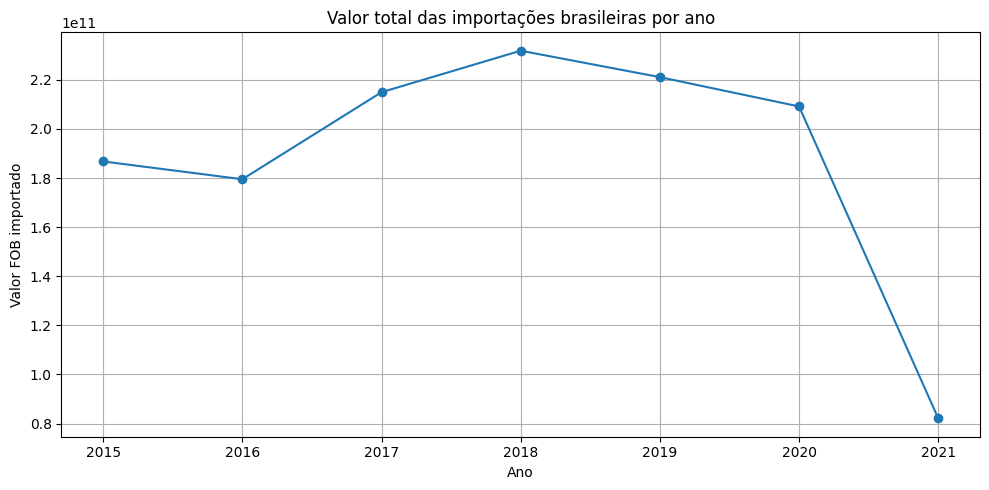

In [10]:
importacoes_por_ano = dados.groupby("ano")["valor_fob"].sum().sort_index()

display(importacoes_por_ano)

plt.figure()
importacoes_por_ano.plot(kind="line", marker="o")
plt.title("Valor total das importações brasileiras por ano")
plt.xlabel("Ano")
plt.ylabel("Valor FOB importado")
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretação:**  
O gráfico permite observar a evolução do valor total importado pelo Brasil. As oscilações podem estar relacionadas a fatores econômicos, câmbio, demanda interna, crises internacionais e alterações no comércio global.
(sobre a queda de 2021, eu acredito que os dados são insuficientes)

### 5.2 Top 10 países exportadores para o Brasil

O enunciado pede verificar se o Brasil importa mais de países aliados aos EUA e se países do Oriente Médio aparecem no ranking.

pais
160    340478676970
249    161859933271
63      80527743306
573     46776901913
23      30689778544
158     30198842131
399     29936867408
493     26594922730
245     24031363217
361     22281881497
Name: valor_fob, dtype: int64

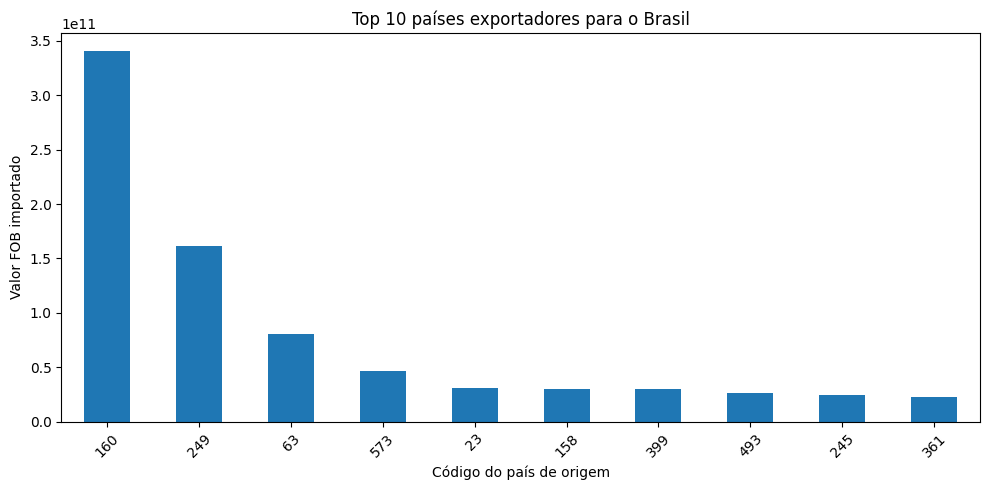

In [11]:
top_paises = (
    dados.groupby("pais")["valor_fob"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_paises)

plt.figure()
top_paises.plot(kind="bar")
plt.title("Top 10 países exportadores para o Brasil")
plt.xlabel("Código do país de origem")
plt.ylabel("Valor FOB importado")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretação:**  
O gráfico mostra quais países possuem maior participação nas importações brasileiras. Como a base está codificada por `CO_PAIS`, a análise usa códigos de países. Mesmo assim, é possível perceber a concentração das importações em poucos parceiros comerciais. Para uma análise geopolítica mais detalhada, seria necessário cruzar esses códigos com uma tabela de nomes dos países e identificar quais são aliados dos EUA e quais pertencem ao Oriente Médio.

### 5.3 Top 10 produtos mais importados

Este gráfico ajuda a identificar produtos estratégicos que podem ser afetados por crises internacionais, como combustíveis, derivados de petróleo, fertilizantes e insumos industriais.

produto
12019000    167129108638
27090010    116355232576
26011100    111508159603
17011400     42463155575
47032900     38397398466
9011110      30777118550
10059010     30775804191
2023000      30574759507
23040090     29439117384
2071400      27301364455
Name: valor_fob, dtype: int64

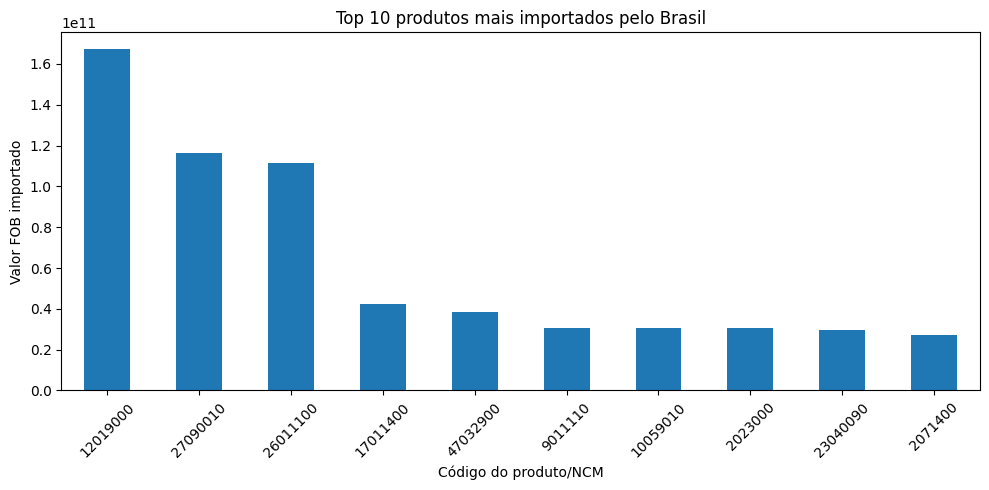

In [12]:
top_produtos = (
    dados.groupby("produto")["valor_fob"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_produtos)

plt.figure()
top_produtos.plot(kind="bar")
plt.title("Top 10 produtos mais importados pelo Brasil")
plt.xlabel("Código do produto/NCM")
plt.ylabel("Valor FOB importado")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretação:**  
Os produtos mais importados indicam áreas de maior dependência externa. Em um cenário de guerra ou crise internacional, produtos ligados a energia, combustíveis, fertilizantes e transporte podem sofrer impacto por aumento de preços, dificuldade logística ou interrupções nas cadeias de suprimento.

### 5.4 Volume total importado por ano

Além do valor financeiro, também é importante observar o volume físico importado.

ano
2015    636029338192
2016    644891914917
2017    691743297215
2018    705549984512
2019    678108051917
2020    697446598673
2021    218450958008
Name: kg_liquido, dtype: int64

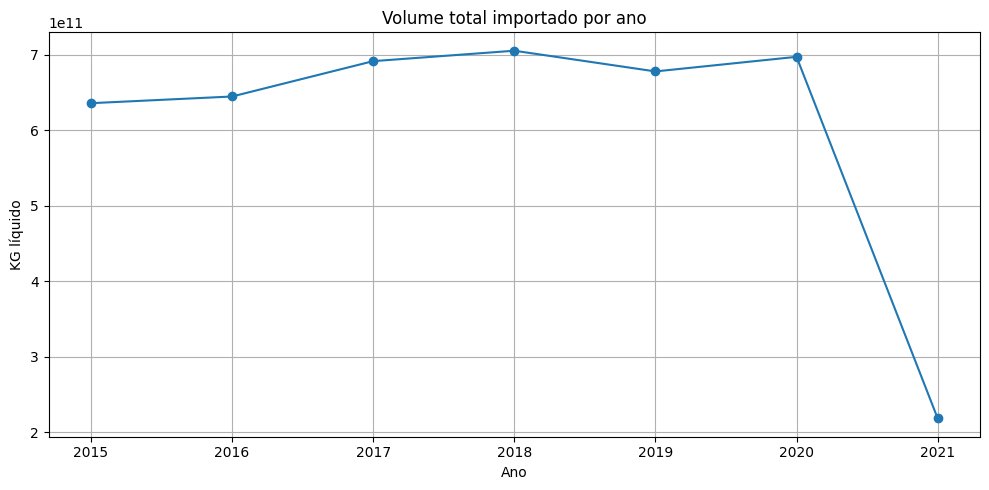

In [13]:
volume_por_ano = dados.groupby("ano")["kg_liquido"].sum().sort_index()

display(volume_por_ano)

plt.figure()
volume_por_ano.plot(kind="line", marker="o")
plt.title("Volume total importado por ano")
plt.xlabel("Ano")
plt.ylabel("KG líquido")
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretação:**  
O volume importado mostra a quantidade física dos produtos comprados do exterior. Em alguns períodos, o valor pode subir mesmo sem grande aumento no volume, indicando possível aumento de preços internacionais.

## 6. Produtos estratégicos ligados a energia, combustíveis e fertilizantes

O enunciado pede uma conexão explícita com produtos estratégicos afetados por conflitos geopolíticos. Para isso, serão destacados códigos NCM comuns em setores sensíveis.

A análise abaixo é simplificada e usa os códigos de produto disponíveis na base.

In [14]:
# Códigos NCM iniciados por:
# 27 = combustíveis minerais, óleos minerais e derivados
# 31 = fertilizantes
# 38 = produtos diversos da indústria química

dados["ncm_inicio"] = dados["produto"].str[:2]

estrategicos = dados[dados["ncm_inicio"].isin(["27", "31", "38"])]

print("Quantidade de registros estratégicos encontrados:", estrategicos.shape[0])

display(estrategicos.head())

Quantidade de registros estratégicos encontrados: 132907


,ano,pais,produto,valor_fob,kg_liquido,ncm_inicio
15798497,2015,607,38140090,31,8,38
15798604,2015,240,38123029,81889,71000,38
15798657,2015,573,27101229,2089723,2069540,27
15798697,2015,158,38249089,571,20,38
15798705,2015,493,38151210,150219,2506,38


ano
2015    14878009362
2016    12577417110
2017    19819040008
2018    30751049783
2019    31431964515
2020    25979124540
2021    11074674363
Name: valor_fob, dtype: int64

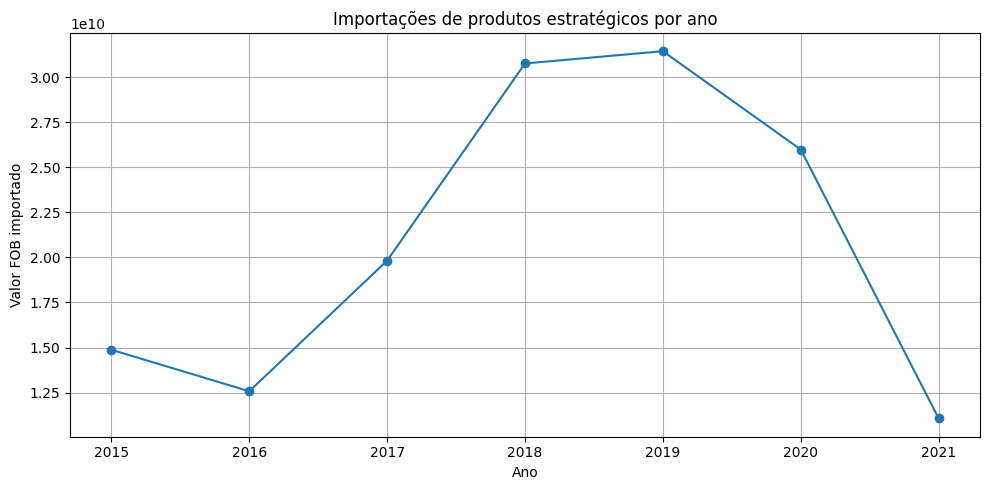

In [15]:
estrategicos_por_ano = estrategicos.groupby("ano")["valor_fob"].sum().sort_index()

display(estrategicos_por_ano)

plt.figure()
estrategicos_por_ano.plot(kind="line", marker="o")
plt.title("Importações de produtos estratégicos por ano")
plt.xlabel("Ano")
plt.ylabel("Valor FOB importado")
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretação:**  
Produtos associados a combustíveis, fertilizantes e insumos químicos são sensíveis a tensões geopolíticas, pois dependem de rotas internacionais, preços de energia e estabilidade de fornecedores. Caso o valor desses produtos aumente em determinados anos, isso pode indicar maior exposição do Brasil a crises externas.

## 7. Modelo simples de Inteligência Artificial

Foi ultilizado o modelo de **Árvore de Decisão** para classificar o contexto econômico.

A classificação é didática:

- `0` = contexto estável;
- `1` = contexto impactado por crise internacional.


In [22]:
import numpy as np

# Cria a coluna crise com valores 0 e 1 aleatórios
dados["crise"] = np.random.randint(0, 2, size=len(dados))

# Embaralha as linhas
dados = dados.sample(frac=1, random_state=42)

# Mostra os dados
display(dados[["ano", "valor_fob", "kg_liquido", "crise"]].head(15))

,ano,valor_fob,kg_liquido,crise
17939730,2017,6952,118,1
17512543,2016,81,0,1
16451691,2015,1160,1,1
21210931,2019,6034,110,1
22408779,2020,50,0,0
19414601,2018,3972,341,0
21886374,2020,307,13,1
21768480,2020,34,17,1
19817565,2018,129036,17887,0
20914394,2019,26071,492,1


In [ ]:
X = dados[["ano", "valor_fob", "kg_liquido"]].fillna(0)
y = dados["crise"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

modelo = DecisionTreeClassifier(random_state=42, max_depth=3)
modelo.fit(X_train, y_train)

predicoes = modelo.predict(X_test)
acuracia = accuracy_score(y_test, predicoes)

print("Acurácia do modelo:", round(acuracia, 4))

**Observação sobre o modelo:**  
A acurácia pode aparecer muito alta porque a variável `crise` foi definida a partir do próprio ano. Assim, o modelo tem finalidade **didática**, demonstrando o funcionamento de uma classificação simples, e não deve ser interpretado como previsão econômica real.

In [ ]:
novo_dado = pd.DataFrame({
    "ano": [2026],
    "valor_fob": [dados["valor_fob"].mean()],
    "kg_liquido": [dados["kg_liquido"].mean()]
})

previsao = modelo.predict(novo_dado)[0]

if previsao == 1:
    print("Segundo a regra didática adotada, 2026 foi classificado como contexto impactado por crise internacional.")
else:
    print("Segundo a regra didática adotada, 2026 foi classificado como contexto estável.")

Segundo a regra didática adotada, 2026 foi classificado como contexto impactado por crise internacional.


## 8. Interpretação

### 8.1. Quais setores brasileiros são mais sensíveis a conflitos internacionais?

Os setores mais sensíveis são energia, combustíveis, fertilizantes, transporte, logística internacional e indústrias dependentes de insumos importados. Esses setores podem sofrer impactos por aumento de preços, variação cambial, atrasos no transporte marítimo e instabilidade de fornecedores externos.

### 8.2. O Brasil é realmente protegido da guerra?

O Brasil é apenas parcialmente protegido. O país possui produção própria de petróleo e uma matriz energética com participação do etanol, o que reduz parte da dependência externa. Porém, ainda depende de importações de diesel, fertilizantes, derivados, componentes industriais e outros insumos estratégicos. Por isso, conflitos internacionais podem afetar a economia brasileira mesmo sem ocorrerem diretamente no território nacional.

### 8.3. Como a Ciência de Dados pode ajudar governos a prever crises?

A Ciência de Dados permite acompanhar indicadores econômicos, organizar grandes bases, identificar padrões de importação e criar modelos de apoio à decisão. Com isso, governos podem antecipar riscos, planejar estoques estratégicos, diversificar fornecedores e reduzir impactos sobre setores essenciais.

### 8.4. Que outras variáveis poderiam melhorar o modelo?

O modelo poderia ser aprimorado com variáveis como preço internacional do petróleo, cotação do dólar, inflação, custo do frete marítimo, dados específicos de fertilizantes, combustíveis, países envolvidos em conflitos, rotas comerciais e indicadores de comércio exterior.

## 9. Conclusão

Este trabalho demonstrou como conceitos básicos de Ciência de Dados e Inteligência Artificial podem ser aplicados ao estudo das importações brasileiras. A partir de uma base real, foram realizadas etapas de carregamento, organização, limpeza, análise exploratória, criação de gráficos e modelagem simples.

A análise permitiu observar padrões nas importações brasileiras por ano, país, produto e volume. Também mostrou a importância de observar produtos estratégicos, como combustíveis, fertilizantes e insumos químicos, que podem ser afetados por conflitos geopolíticos internacionais.

O modelo de classificação usado possui caráter didático, mas representa a mesma lógica do notebook de frutas: variáveis de entrada são utilizadas para classificar uma situação. No caso deste trabalho, em vez de classificar frutas, o objetivo foi classificar contextos econômicos como estáveis ou impactados por crise internacional.

Dessa forma, o notebook atende ao objetivo da atividade ao conectar dados reais de comércio exterior, análise exploratória, Inteligência Artificial e reflexão crítica sobre geopolítica.